#Preparação do Ambiente e Geração dos Dados

In [1]:
# Célula 1: Importações e Setup dos Dados
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Configuração visual para os gráficos
plt.style.use('seaborn-v0_8-whitegrid')

# Geração de dados sintéticos: Comportamento em Minigames
np.random.seed(42)
n_samples = 1000

dados = pd.DataFrame({
    'tempo_reacao_ms': np.random.normal(250, 60, n_samples),
    'cliques_por_minuto': np.random.normal(85, 25, n_samples),
    'erros_mecanicos': np.random.poisson(2, n_samples),
    'movimento_erratico_mouse': np.random.normal(15, 8, n_samples),
    'tempo_conclusao_s': np.random.normal(120, 35, n_samples)
})

# Criando a variável alvo (engajamento_alto) com base em regras logísticas e ruído
log_odds = (
    - 0.02 * dados['tempo_reacao_ms']
    + 0.05 * dados['cliques_por_minuto']
    - 0.50 * dados['erros_mecanicos']
    + np.random.normal(0, 1, n_samples) # Ruído inerente ao comportamento humano
)
probabilidade = 1 / (1 + np.exp(-log_odds))
dados['engajamento_alto'] = (probabilidade > 0.5).astype(int)

# Separação de Treino e Teste
X = dados.drop('engajamento_alto', axis=1)
y = dados['engajamento_alto']
features = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Dimensão de Treino: {X_train.shape} | Dimensão de Teste: {X_test.shape}")

Dimensão de Treino: (700, 5) | Dimensão de Teste: (300, 5)


#Decision Tree (Árvore de Decisão Simples)

Aqui, vamos treinar uma única árvore. Nota técnica importante: Limitei propositalmente o max_depth=3. Se deixarmos a árvore crescer livremente, o gráfico hierárquico se tornará um emaranhado de nós ilegível no notebook.

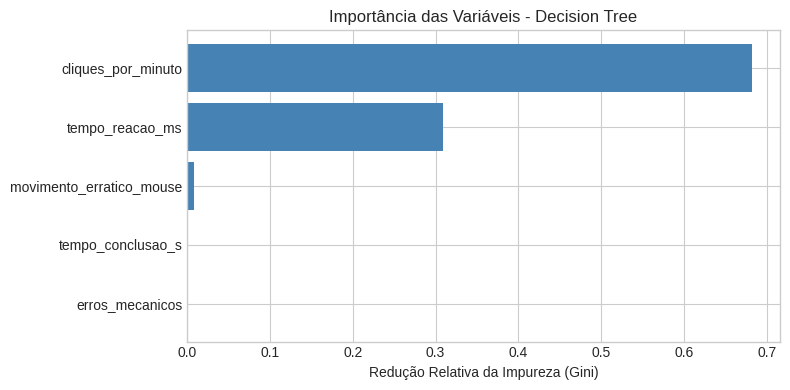

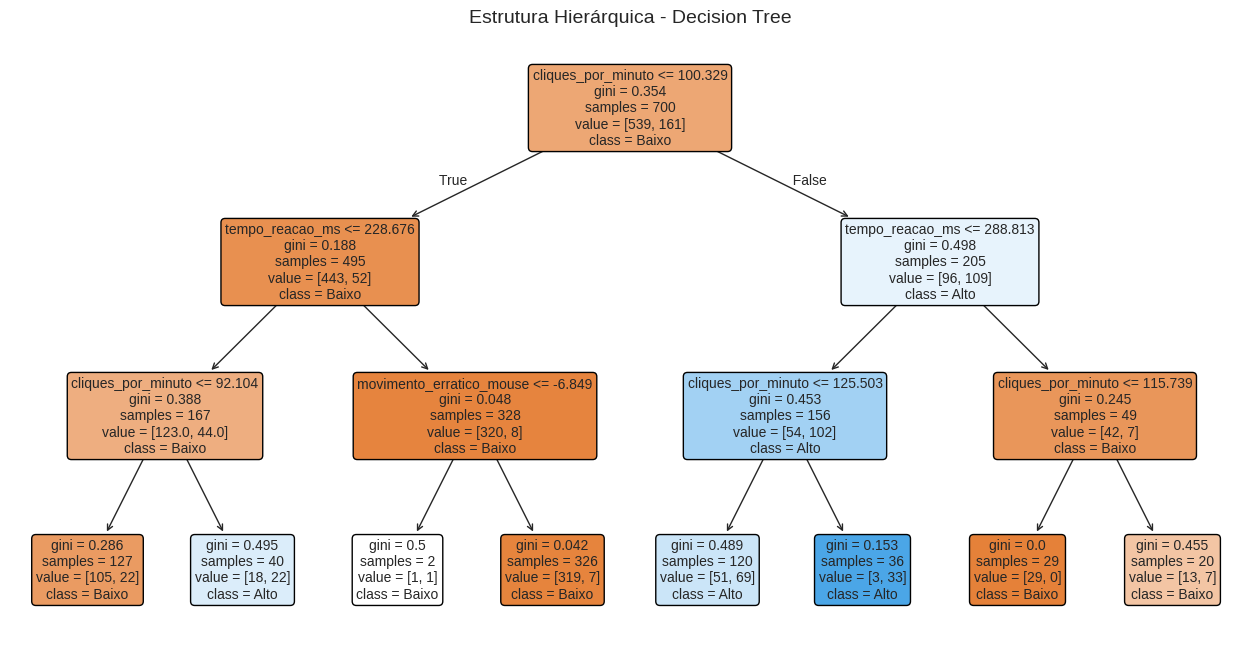

In [2]:
# Célula 2: Treinamento e Visualização da Decision Tree
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42, criterion='gini')
dt_model.fit(X_train, y_train)

# 1. Gráfico de Importância das Variáveis
plt.figure(figsize=(8, 4))
importancias_dt = dt_model.feature_importances_
indices_dt = np.argsort(importancias_dt)
plt.barh(range(len(indices_dt)), importancias_dt[indices_dt], color='steelblue')
plt.yticks(range(len(indices_dt)), [features[i] for i in indices_dt])
plt.title('Importância das Variáveis - Decision Tree')
plt.xlabel('Redução Relativa da Impureza (Gini)')
plt.tight_layout()
plt.show()

# 2. Gráfico da Hierarquia da Árvore
plt.figure(figsize=(16, 8))
plot_tree(dt_model,
          feature_names=features,
          class_names=['Baixo', 'Alto'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Estrutura Hierárquica - Decision Tree', fontsize=14)
plt.show()

#Random Forest (Floresta Aleatória)

Como o Random Forest é um conjunto de centenas de árvores, não faz sentido (e é visualmente impossível) plotar a floresta inteira. A abordagem padrão para interpretabilidade aqui é plotar a importância global das variáveis (que é a média da importância em todas as árvores) e extrair apenas um estimador (uma árvore) para ilustrar a estrutura.

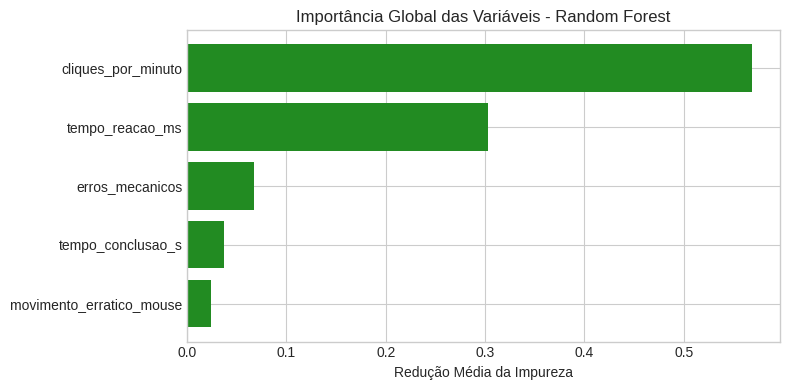

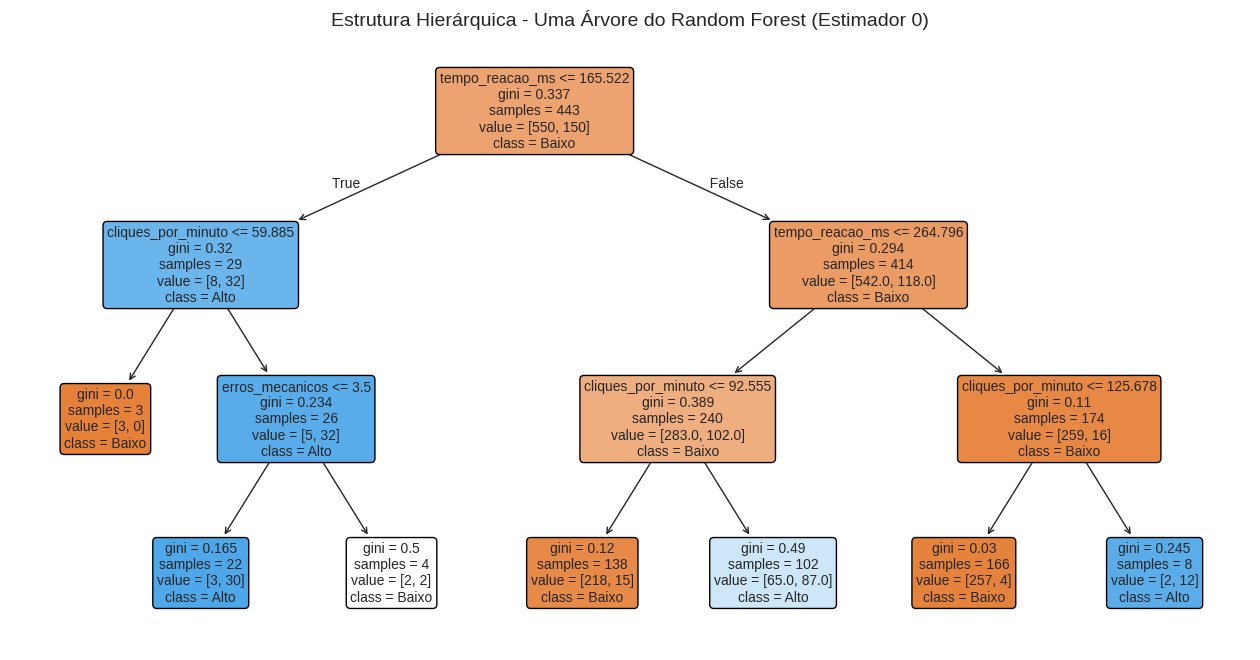

In [3]:
# Célula 3: Treinamento e Visualização do Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
rf_model.fit(X_train, y_train)

# 1. Gráfico de Importância das Variáveis (Média da Floresta)
plt.figure(figsize=(8, 4))
importancias_rf = rf_model.feature_importances_
indices_rf = np.argsort(importancias_rf)
plt.barh(range(len(indices_rf)), importancias_rf[indices_rf], color='forestgreen')
plt.yticks(range(len(indices_rf)), [features[i] for i in indices_rf])
plt.title('Importância Global das Variáveis - Random Forest')
plt.xlabel('Redução Média da Impureza')
plt.tight_layout()
plt.show()

# 2. Gráfico de UM Estimador da Floresta (A 1ª Árvore)
plt.figure(figsize=(16, 8))
# Extraímos a árvore de índice 0 do ensemble
arvore_exemplo_rf = rf_model.estimators_[0]
plot_tree(arvore_exemplo_rf,
          feature_names=features,
          class_names=['Baixo', 'Alto'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Estrutura Hierárquica - Uma Árvore do Random Forest (Estimador 0)', fontsize=14)
plt.show()

#Gradient Boosting

A lógica de visualização do Gradient Boosting requer um cuidado analítico extra. As árvores deste modelo não preveem a classe final ("Alto" ou "Baixo" engajamento) diretamente. A primeira árvore tenta fazer uma previsão base, e as árvores subsequentes preveem os resíduos (erros) matemáticos contínuos.

Por isso, ao plotar uma árvore de um classificador Gradient Boosting, os valores nas folhas (o value) não representarão a contagem de classes, mas sim a contribuição bruta (log-odds) para a correção do erro.

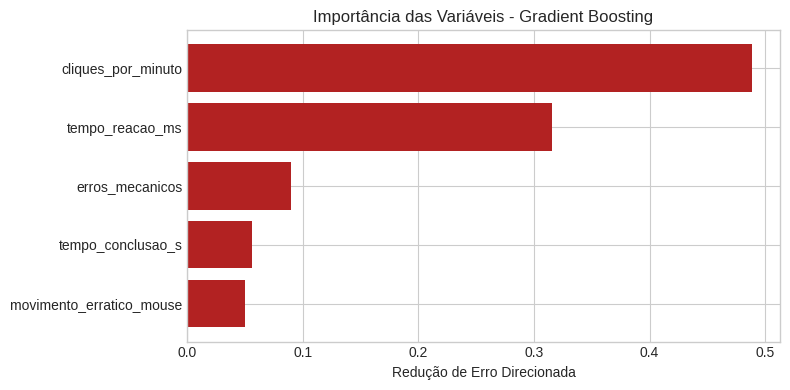

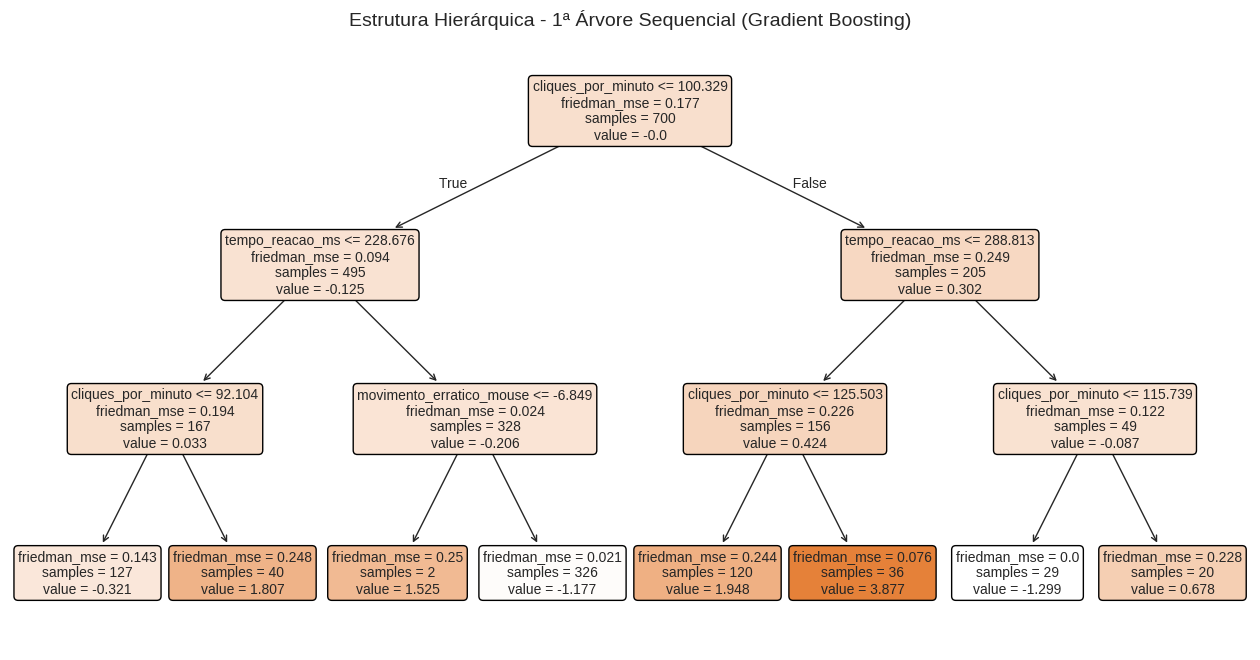

In [4]:
# Célula 4: Treinamento e Visualização do Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train, y_train)

# 1. Gráfico de Importância das Variáveis
plt.figure(figsize=(8, 4))
importancias_gb = gb_model.feature_importances_
indices_gb = np.argsort(importancias_gb)
plt.barh(range(len(indices_gb)), importancias_gb[indices_gb], color='firebrick')
plt.yticks(range(len(indices_gb)), [features[i] for i in indices_gb])
plt.title('Importância das Variáveis - Gradient Boosting')
plt.xlabel('Redução de Erro Direcionada')
plt.tight_layout()
plt.show()

# 2. Gráfico da 1ª Árvore do Boosting (Árvore de Correção Inicial)
plt.figure(figsize=(16, 8))
# No GB do sklearn, estimators_ é um array 2D: [iteracao, classe]. Para binário, classe é 0.
arvore_inicial_gb = gb_model.estimators_[0, 0]
plot_tree(arvore_inicial_gb,
          feature_names=features,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Estrutura Hierárquica - 1ª Árvore Sequencial (Gradient Boosting)', fontsize=14)
plt.show()

#Calculando as Métricas para Avaliação dos Modelos

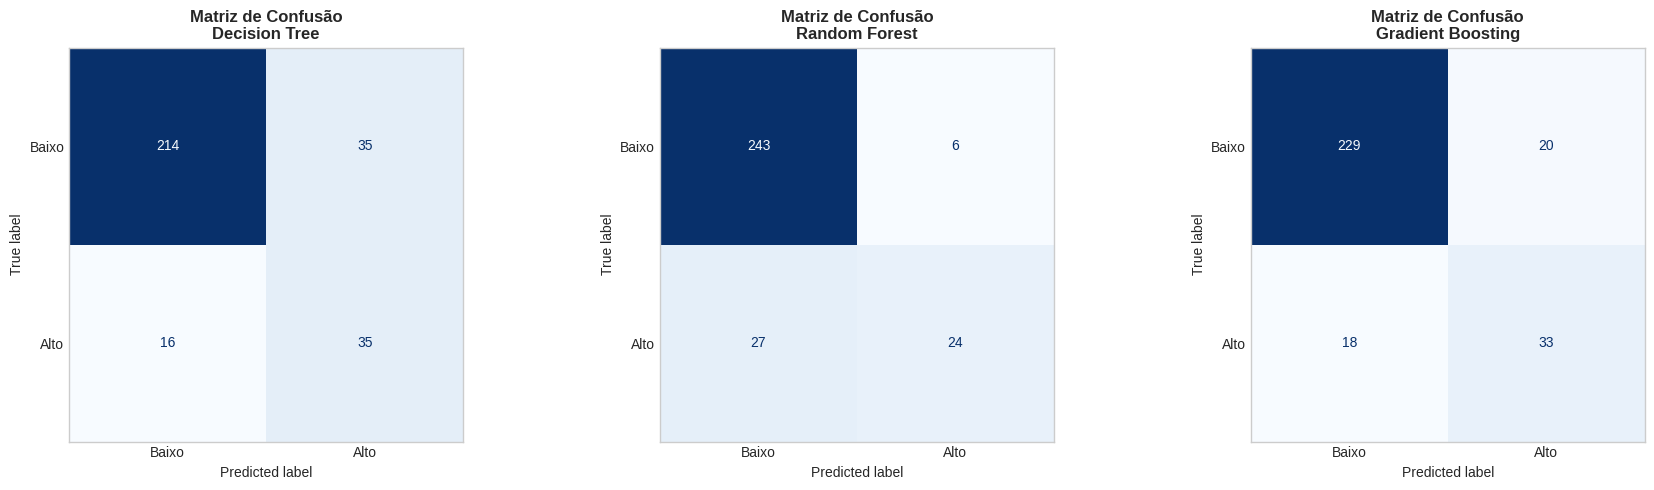


TABELA COMPARATIVA DE PERFORMANCE (DADOS DE TESTE)


,Acurácia,Precisão,Recall,F1-Score
Modelo,,,,
Decision Tree,0.8300,0.5000,0.6863,0.5785
Random Forest,0.8900,0.8000,0.4706,0.5926
Gradient Boosting,0.8733,0.6226,0.6471,0.6346


In [5]:
# Célula 5: Avaliação de Performance e Matriz de Confusão
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Criando um dicionário para iterar de forma mais limpa
modelos = {
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'Gradient Boosting': gb_model
}

# Lista para armazenar as métricas e consolidar em um DataFrame
resultados_metricas = []

# Configuração da figura para plotar as 3 matrizes lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (nome, modelo) in enumerate(modelos.items()):
    # 1. Gerando as previsões com os dados de teste (X_test)
    y_pred = modelo.predict(X_test)

    # 2. Calculando as métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    resultados_metricas.append({
        'Modelo': nome,
        'Acurácia': acc,
        'Precisão': prec,
        'Recall': rec,
        'F1-Score': f1
    })

    # 3. Plotando a Matriz de Confusão
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Baixo', 'Alto'])

    # Renderizando no subplot específico (axes[idx])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(f'Matriz de Confusão\n{nome}', fontsize=12, fontweight='bold')
    axes[idx].grid(False) # Remove o grid de fundo para não poluir a matriz

plt.tight_layout()
plt.show()

# 4. Exibindo a tabela comparativa de resultados
df_resultados = pd.DataFrame(resultados_metricas).set_index('Modelo')
print("\n" + "="*50)
print("TABELA COMPARATIVA DE PERFORMANCE (DADOS DE TESTE)")
print("="*50)
display(df_resultados.round(4)) # Exibe arredondando para 4 casas decimais

#Tuning de Hiperparâmetros com GridSearchCV

In [6]:
# Célula 6: Hyperparameter Tuning com GridSearchCV
from sklearn.model_selection import GridSearchCV

# 1. Definindo a "Grade" de Hiperparâmetros
# CUIDADO: O número total de treinamentos será a multiplicação de todas as opções vezes o CV.
# Aqui temos: 3 * 3 * 2 * 2 = 36 combinações. Com CV=5, serão 180 treinamentos!
param_grid_gb = {
    'n_estimators': [50, 100, 200],       # Número de árvores sequenciais
    'learning_rate': [0.01, 0.1, 0.2],    # O passo de aprendizado (trade-off com n_estimators)
    'max_depth': [3, 5],                  # Profundidade para evitar overfitting nas árvores individuais
    'min_samples_split': [2, 10]          # Restrição de quebra nos nós
}

# 2. Instanciando o modelo base (sem parâmetros)
gb_base = GradientBoostingClassifier(random_state=42)

# 3. Configurando o GridSearchCV
print("Iniciando a busca em grade. Isso pode levar alguns segundos...\n")
grid_search = GridSearchCV(
    estimator=gb_base,
    param_grid=param_grid_gb,
    scoring='f1',       # Nossa métrica alvo: otimizar o equilíbrio entre Precisão e Recall
    cv=5,               # Validação Cruzada com 5 folds
    n_jobs=-1,          # Usa todos os núcleos do seu processador para rodar em paralelo
    verbose=1           # Mostra o progresso no console
)

# 4. Executando o treinamento
grid_search.fit(X_train, y_train)

# 5. Extraindo os melhores resultados
melhor_modelo_gb = grid_search.best_estimator_

print("\n" + "="*50)
print("RESULTADOS DO GRID SEARCH")
print("="*50)
print(f"Melhores Hiperparâmetros encontrados:\n{grid_search.best_params_}\n")
print(f"Melhor F1-Score na Validação Cruzada (Treino): {grid_search.best_score_:.4f}")

# 6. Avaliando o modelo otimizado nos dados de Teste (dados nunca vistos)
y_pred_otimizado = melhor_modelo_gb.predict(X_test)
f1_teste_otimizado = f1_score(y_test, y_pred_otimizado)

print(f"F1-Score nos Dados de Teste: {f1_teste_otimizado:.4f}")

Iniciando a busca em grade. Isso pode levar alguns segundos...

Fitting 5 folds for each of 36 candidates, totalling 180 fits

RESULTADOS DO GRID SEARCH
Melhores Hiperparâmetros encontrados:
{'learning_rate': 0.01, 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}

Melhor F1-Score na Validação Cruzada (Treino): 0.6516
F1-Score nos Dados de Teste: 0.6667


# 🏆 Desafio Prático: Otimização de Churn com Modelos de Árvore

**Cenário:** Uma empresa de streaming está perdendo clientes (Churn) e você foi contratado para criar o modelo preditivo final. O objetivo não é apenas ter uma acurácia alta, mas garantir que o modelo não esteja "decorando" (overfitting) os dados dos clientes antigos.

**Seu objetivo:**
1. Treinar um modelo de **Gradient Boosting**.
2. Realizar uma busca de hiperparâmetros para encontrar o melhor equilíbrio entre viés e variância.
3. Comparar o impacto da poda (pruning) na performance de teste.

---
### 🛠️ Exercício Proposto

In [7]:
# Importações necessárias
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.datasets import make_classification # Simulando dados de churn
import numpy as np

# 1. Gerando um dataset sintético de Churn (1000 clientes, 20 características)
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Defina o espaço de busca de hiperparâmetros baseado na Aula 04
# Tente variar: learning_rate, n_estimators, max_depth e subsample
param_dist = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [50, 100, 200, 500],
    'max_depth': [3, 5, 10, None],
    'subsample': [0.5, 0.7, 0.8, 1.0],
    'min_samples_split': [2, 10, 20]
}

# 3. Implemente o RandomizedSearchCV (Estratégia da Aula 03)
model = GradientBoostingClassifier(random_state=42)
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    verbose=1,
    random_state=42
)

# Executando a busca
random_search.fit(X_train, y_train)

# 4. TAREFA PARA VOCÊ:
print(f"Melhores hiperparâmetros encontrados: {random_search.best_params_}")
print(f"Acurácia no Teste: {random_search.score(X_test, y_test):.4f}")

# PERGUNTA REFLEXIVA:
# Observando o 'max_depth' e o 'n_estimators' escolhidos, o modelo tende a ser
# mais simples (generalista) ou complexo (propenso a overfitting)? Justifique com base no material.

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Melhores hiperparâmetros encontrados: {'subsample': 0.7, 'n_estimators': 200, 'min_samples_split': 20, 'max_depth': 5, 'learning_rate': 0.1}
Acurácia no Teste: 0.8900


# 🏆 Agora é contigo!

Você recebeu um conjunto de dados sintético que representa o perfil de crédito de clientes.

Sua missão é configurar uma "Floresta" que seja robusta e não sofra com a alta variância.

**Instruções:**

- Execute a célula abaixo para gerar os dados.

- Implemente um modelo de Random Forest.

- Utilize a estratégia de Grid Search para testar todas as combinações de uma grade de parâmetros pré-definida.

- Avalie o modelo final utilizando as métricas de Acurácia, Precisão e Recall (especialmente importante em crédito para evitar falsos negativos).

In [10]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# --- 1. GERAÇÃO DE DADOS (Professor) ---
# Simulando 1500 clientes com 10 variáveis (renda, idade, histórico, etc.)
X, y = make_classification(
    n_samples=1500,
    n_features=10,
    n_informative=7,
    n_redundant=3,
    random_state=123
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)

print("Dados gerados com sucesso! Agora é sua vez.")

# --- 2. TAREFA ---
# ESCREVA SEU CÓDIGO ABAIXO:

# --- 2. MODELO RANDOM FOREST ---

rf = RandomForestClassifier(random_state=123)

# Grade de parâmetros para testar
param_grid = {
    'n_estimators': [50, 100, 200],      # quantidade de árvores
    'max_depth': [None, 5, 10, 20],      # profundidade das árvores
    'min_samples_split': [2, 5, 10],     # mínimo para dividir nó
    'min_samples_leaf': [1, 2, 4]        # mínimo de amostras na folha
}

# Grid Search com validação cruzada
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='recall',   # focando em evitar falsos negativos
    n_jobs=-1
)

# Treinamento
grid_search.fit(X_train, y_train)

# Melhor modelo encontrado
best_model = grid_search.best_estimator_

print("Melhores parâmetros encontrados:")
print(grid_search.best_params_)

# --- 3. AVALIAÇÃO DO MODELO ---

y_pred = best_model.predict(X_test)

print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred))

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

print("Melhor recall na validação cruzada:", grid_search.best_score_)

Dados gerados com sucesso! Agora é sua vez.
Melhores parâmetros encontrados:
{'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}

Matriz de Confusão:
[[187  32]
 [ 26 205]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.88      0.85      0.87       219
           1       0.86      0.89      0.88       231

    accuracy                           0.87       450
   macro avg       0.87      0.87      0.87       450
weighted avg       0.87      0.87      0.87       450

Melhor recall na validação cruzada: 0.9273626373626375
